# Day 1: induction-head detection and proof on Pythia-410M

This notebook is the Day 1 artifact for the pilot. It does two things:

**Part A — detection.** Run Olsson's prefix-matching detector on every (layer, head) pair in Pythia-410M @ `step143000`. The Day 1 gate (`PROJECT_BRIEF.md` §3) is met if at least one head scores above 0.5.

**Part B — proof.** Demonstrate that the heads selected by the detector are doing actual induction work — not just scoring high on a statistical proxy — via six independent views:

1. **Geometric intuition** — induction is a *shifted diagonal* in the attention matrix; the offset *is* the algorithm.
2. **Worked example** — `A B C A B C`, showing the off-diagonal as three star markers and the model's correct next-token predictions.
3. **Bird's-eye view** of all 384 heads on a synthetic repeated-token sequence.
4. **Focused comparison** of top candidates vs. a low-scoring control.
5. **Per-layer detail on real text** with token-labeled axes.
6. **Token-level prediction and causal ablation** — the strongest test.

Visual style: attention-pattern plots use upper-triangular masking (`numpy.ma.masked_array`) to blank causal-zero positions, so the meaningful lower-triangular values stand out.

## Setup

In [1]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import torch
import numpy as np
import matplotlib.pyplot as plt

from src.utils.pythia_loader import load_pythia
from src.detectors.induction import build_repetition_sequences, prefix_matching_score

torch.set_grad_enabled(False)
model = load_pythia('410m', step=143000)
device = next(model.parameters()).device
n_layers, n_heads = int(model.cfg.n_layers), int(model.cfg.n_heads)
print(f'model loaded: n_layers={n_layers}, n_heads={n_heads}, device={device}')

/Users/cberg/Documents/Emergence_Research/pythia-motif-emergence/.venv/lib/python3.12/site-packages/transformer_lens/config/HookedTransformerConfig.py:341: UserWarning: MPS backend may produce silently incorrect results (PyTorch 2.11.0). Set TRANSFORMERLENS_ALLOW_MPS=1 to suppress this warning. See: https://github.com/TransformerLensOrg/TransformerLens/issues/1178
  warn_if_mps(self.device)


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/pythia-410m-deduped into HookedTransformer
model loaded: n_layers=24, n_heads=16, device=mps:0


In [2]:
def upper_tri_mask(n: int) -> np.ndarray:
    return torch.triu(torch.ones(n, n), diagonal=1).bool().numpy()

## Part A — detection: Olsson prefix-matching score on every head

Build 50 random sequences of length 100, each with the second half a copy of the first half. For each (layer, head), compute the mean attention from second-half positions to the prefix-match target (one position after the previous occurrence of the current token). Average over the 50 sequences.

**Day 1 gate** (`PROJECT_BRIEF.md` §3): pass requires at least one head with score > 0.5.

In [3]:
GATE_THRESHOLD = 0.5
result = prefix_matching_score(model, n_sequences=50, seq_len=100)

# Rank all heads by score.
ranked = [
    (layer, head, float(result.scores[layer, head]))
    for layer in range(n_layers)
    for head in range(n_heads)
]
ranked.sort(key=lambda x: -x[2])

above_gate = [r for r in ranked if r[2] > GATE_THRESHOLD]
print(f'heads with prefix-matching > 0.3: '
      f'{sum(1 for _, _, s in ranked if s > 0.3)}')
print(f'heads with prefix-matching > {GATE_THRESHOLD}: {len(above_gate)}')
print(f'\nDay 1 gate: {"PASS" if above_gate else "FAIL"}')

print('\ntop-10 induction-head candidates (layer, head, score):')
for layer, head, score in ranked[:10]:
    marker = '  <-- gate' if score > GATE_THRESHOLD else ''
    print(f'  L{layer:2d}H{head:2d}: {score:.4f}{marker}')

# Use the top-3 as our induction candidates throughout the rest of the notebook.
TOP_HEADS = [(layer, head) for layer, head, _ in ranked[:3]]
# Control: lowest-scoring head from layer 0 (too-early to plausibly do induction).
layer0 = sorted(
    [(0, h, float(result.scores[0, h])) for h in range(n_heads)], key=lambda x: x[2]
)
CONTROL_HEAD = (layer0[0][0], layer0[0][1])
print(f'\nTOP_HEADS    = {TOP_HEADS}')
print(f'CONTROL_HEAD = {CONTROL_HEAD}')

heads with prefix-matching > 0.3: 19
heads with prefix-matching > 0.5: 11

Day 1 gate: PASS

top-10 induction-head candidates (layer, head, score):
  L11H14: 0.9526  <-- gate
  L11H 2: 0.9365  <-- gate
  L 7H 1: 0.9301  <-- gate
  L 8H 6: 0.8315  <-- gate
  L10H 9: 0.8174  <-- gate
  L10H 3: 0.8155  <-- gate
  L 8H 7: 0.7886  <-- gate
  L 6H 2: 0.7750  <-- gate
  L10H 0: 0.6626  <-- gate
  L15H 0: 0.5884  <-- gate

TOP_HEADS    = [(11, 14), (11, 2), (7, 1)]
CONTROL_HEAD = (0, 9)


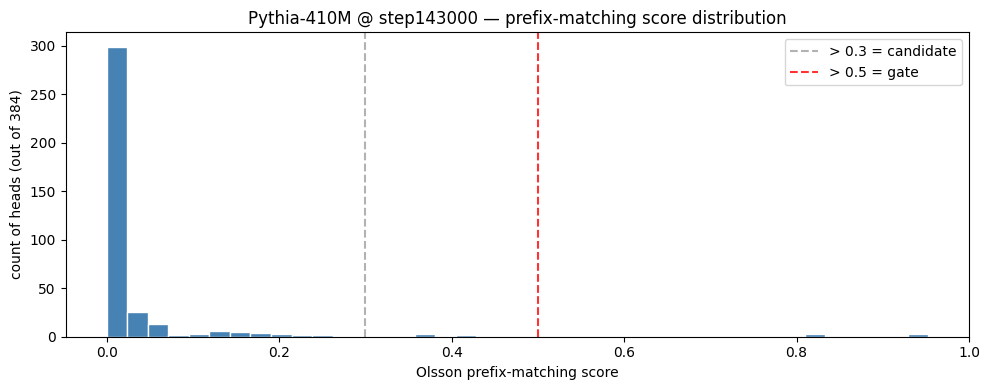

In [4]:
# Score-distribution histogram: where does the prefix-matching mass concentrate?
fig, ax = plt.subplots(figsize=(10, 4))
all_scores = np.array([s for _, _, s in ranked])
ax.hist(all_scores, bins=40, color='steelblue', edgecolor='white')
ax.axvline(0.3, color='gray', linestyle='--', alpha=0.6, label='> 0.3 = candidate')
ax.axvline(GATE_THRESHOLD, color='red', linestyle='--', alpha=0.8, label=f'> {GATE_THRESHOLD} = gate')
ax.set_xlabel('Olsson prefix-matching score')
ax.set_ylabel('count of heads (out of 384)')
ax.set_title('Pythia-410M @ step143000 — prefix-matching score distribution')
ax.legend()
plt.tight_layout()
plt.show()

Reading the histogram: most heads cluster near zero (no prefix-matching). The rightward tail above 0.3 is the candidate pool, and the heads above 0.5 are strong induction candidates. The rest of the notebook investigates whether those rightward-tail heads are doing real induction work or just scoring high by accident.

## Part B — proof

## Geometric intuition: induction is a *shifted diagonal*

Before the bulk evidence, here's the picture in one view. An attention matrix is a coordinate system: the y-axis is the *query* position (where you are now), the x-axis is the *key* position (where you're looking). What pattern does each row of behavior correspond to?

- **Main diagonal** (`q == k`): "attend to yourself" — usually a residual / skip-connection-like pattern, low information content.
- **Just below the diagonal** (`q == k + 1`): "attend to the previous token" — a previous-token head, which is the *upstream* part of the induction circuit.
- **A whole vertical stripe**: "always attend to a special token" (often BOS) — an attention sink.
- **A *shifted* diagonal in the lower-left quadrant**: this is the induction fingerprint. Query at position `q` (in the second half of a repetition) attends to position `q - HALF + 1` — the position *right after* the previous occurrence of the current token.

The shift by `+1` is the whole story. The head matches the current token to its earlier copy, then reads the *next* position — i.e., the token that came after it last time. That's how the model implements "if you see `A B ... A`, predict `B`" without ever storing the rule `A → B` explicitly. It's a translation symmetry in sequence space — the same algorithm fires for any repeated structure.

## A small worked example: `A B C A B C`

Six tokens, structure repeated. At position 3 (the second `A`), the induction head should attend to position 1 (the first `B`, which followed the first `A`) and use that to predict `B` as the next token. Same for position 4 (`B`) → position 2 (`C`), and position 5 (`C`) → position 3 (`A`).

In [5]:
# Note: leading space matters. ' A B C A B C' tokenizes uniformly as six
# space-prefixed tokens; 'A B C A B C' (no leading space) tokenizes the first
# 'A' differently from the second ' A', breaking the induction match.
text_abc = ' A B C A B C'
abc_tokens = model.to_tokens(text_abc, prepend_bos=False)
abc_str = model.to_str_tokens(text_abc, prepend_bos=False)
print('tokens:', list(enumerate(abc_str)))

abc_logits, abc_cache = model.run_with_cache(
    abc_tokens, names_filter=lambda n: n.endswith('pattern'),
)

# What does the model predict at each position?
abc_preds = abc_logits[0].argmax(dim=-1)
print('\nat each position, what does the model predict comes next?')
print(f'  {"pos":>3} {"current":>10} {"top-1 next-token prediction":>32}')
for i, t in enumerate(abc_str):
    pred_str = model.to_string([abc_preds[i].item()])
    print(f'  {i:>3} {t!r:>10} {pred_str!r:>32}')

tokens: [(0, ' A'), (1, ' B'), (2, ' C'), (3, ' A'), (4, ' B'), (5, ' C')]

at each position, what does the model predict comes next?
  pos    current      top-1 next-token prediction
    0       ' A'                              '.'
    1       ' B'                             ' C'
    2       ' C'                             ' D'
    3       ' A'                             ' B'
    4       ' B'                             ' C'
    5       ' C'                             ' A'


<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
/var/folders/_b/6001dkp508q10kk717wvn32m0000gn/T/ipykernel_33771/37231423.py:29: SyntaxWarning: invalid escape sequence '\m'
  ' 2nd A looks to the\n position right after 1st $\mathit{A}$\nto deteremine the next \ntoken in the $\mathit{pattern}$ which \n = $\mathit{B}$',


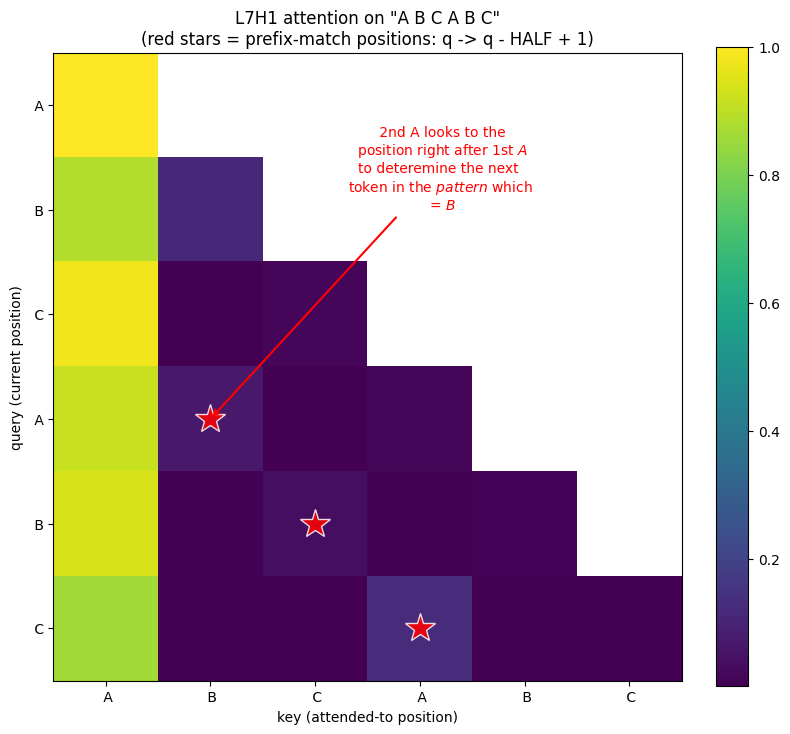

In [24]:
# Visualize attention for one strong induction head on the A B C A B C sequence,
# with star markers on the prefix-match positions and an annotated arrow.
fig, ax = plt.subplots(figsize=(8, 8))
L, H = 7, 1
pat = abc_cache[f'blocks.{L}.attn.hook_pattern'][0, H].detach().cpu().float().numpy()
n_abc = len(abc_str)
mask_abc = upper_tri_mask(n_abc)
pat_masked = np.ma.masked_array(pat, mask_abc)
im = ax.imshow(pat_masked, cmap='viridis')

ax.set_xticks(range(n_abc))
ax.set_yticks(range(n_abc))
ax.set_xticklabels(abc_str)
ax.set_yticklabels(abc_str)
ax.set_xlabel('key (attended-to position)')
ax.set_ylabel('query (current position)')
ax.set_title(f'L{L}H{H} attention on "A B C A B C"\n'
             '(red stars = prefix-match positions: q -> q - HALF + 1)')

half_abc = n_abc // 2
for q in range(half_abc, n_abc):
    k = q - half_abc + 1
    if k < q:
        ax.plot(k, q, marker='*', color='red', markersize=22, alpha=0.85,
                markeredgecolor='white', markeredgewidth=1.0)

# Annotate one cell explicitly: 2nd A (q=3) attends to position after 1st A (k=1).
ax.annotate(
    ' 2nd A looks to the\n position right after 1st $\mathit{A}$\nto deteremine the next \ntoken in the $\mathit{pattern}$ which \n = $\mathit{B}$',
    xy=(1, 3), xytext=(3.2, 1.0),
    fontsize=10, color='red', ha='center',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
)

plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

Reading the figure:

- The bright off-diagonal — three red stars in a line — is the induction fingerprint. Query 3 attends to key 1, query 4 to key 2, query 5 to key 3.
- That line is *parallel* to the main diagonal but offset down-and-left by (HALF − 1) positions. The offset *is* the algorithm: the head finds the same token earlier in the sequence, then shifts forward by 1 to read the next token.
- The text-prediction table above is the same fact in another form: at the second `A`, the model predicts ` B`; at the second `B`, it predicts ` C`. The head's off-diagonal attention is what makes that prediction possible.

**The pattern is the algorithm.** Once you see the shifted diagonal, you've seen induction — the rest of the notebook is showing that this same fingerprint appears consistently across all 384 heads (only a few have it), holds up on real text, drives next-token accuracy, and is causally necessary.

## 1. Bird's-eye view — all 384 heads on a synthetic repeated sequence

Construct a length-100 sequence whose second half is a copy of its first half. Plot the attention pattern of every (layer, head) in Pythia-410M. The induction fingerprint is a bright diagonal in the lower half offset from the main diagonal. Most heads don't show it; the few that do are the candidates the detector selects.

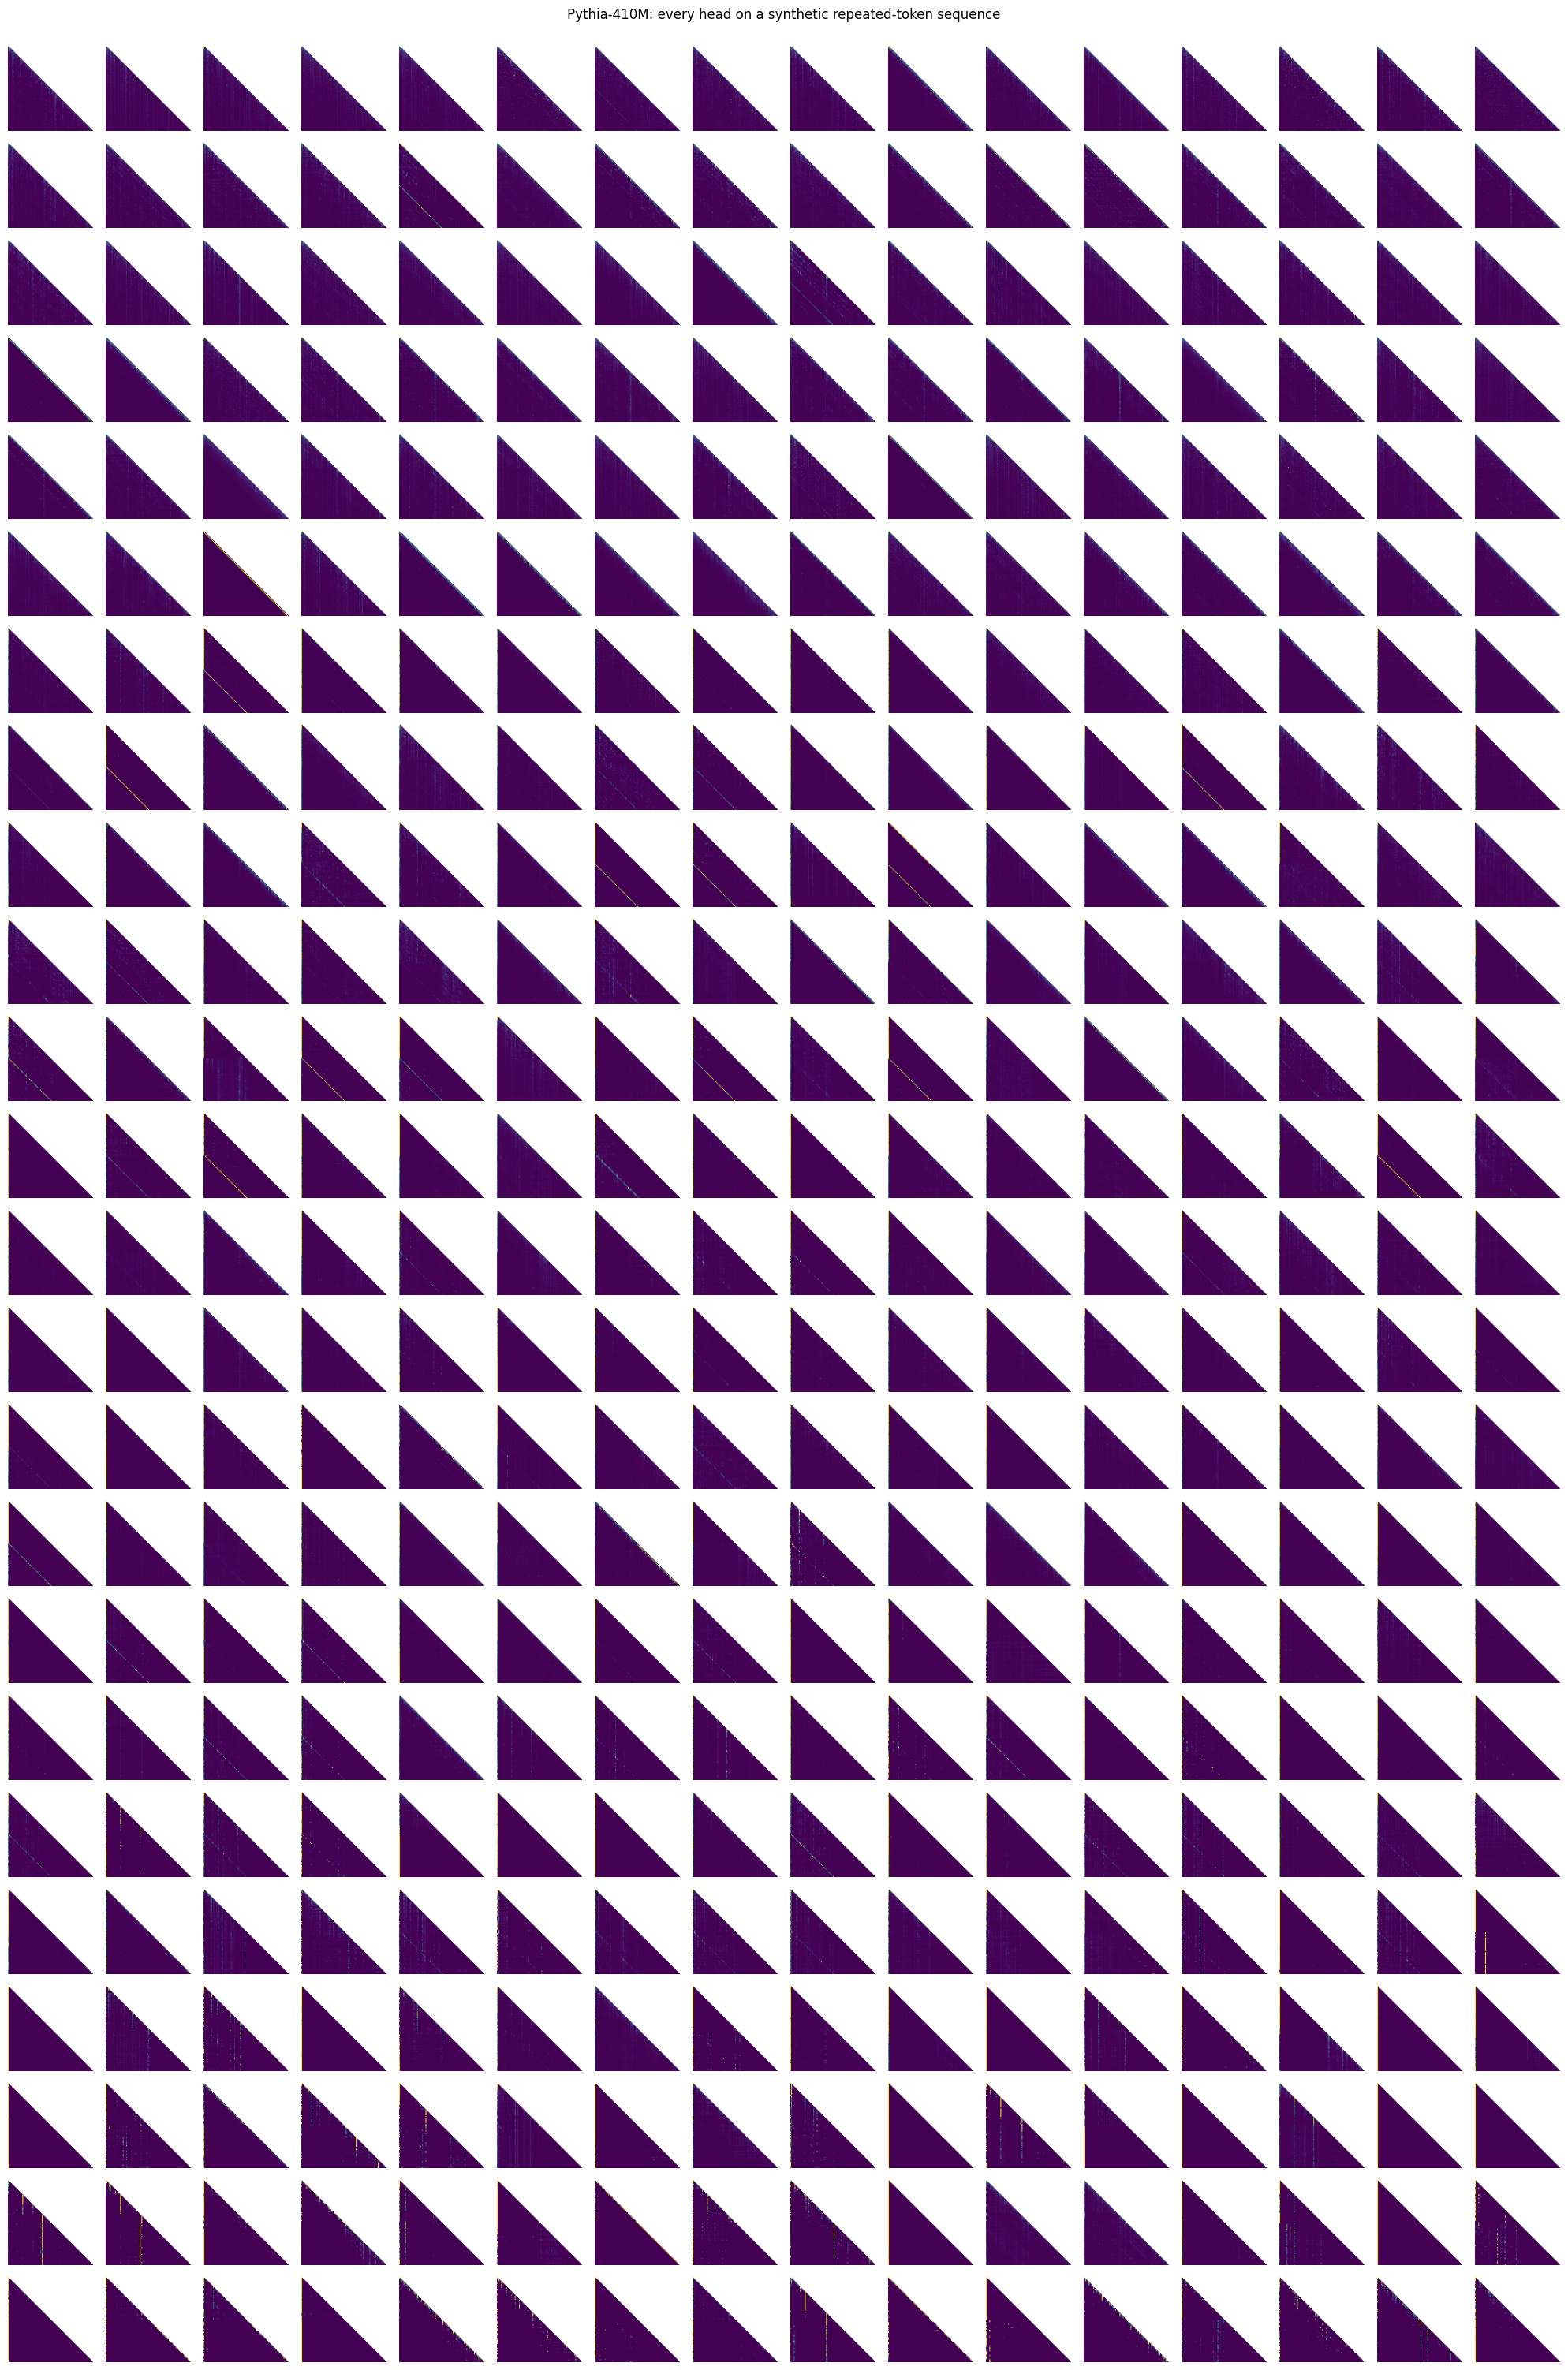

In [7]:
SEQ_LEN = 100
HALF = SEQ_LEN // 2
rng = torch.Generator(device='cpu').manual_seed(42)
synthetic_tokens = build_repetition_sequences(1, SEQ_LEN, model.cfg.d_vocab, rng).to(device)

_, synthetic_cache = model.run_with_cache(
    synthetic_tokens, names_filter=lambda n: n.endswith('pattern'), return_type=None
)

mask_synthetic = upper_tri_mask(SEQ_LEN)

fig = plt.figure(figsize=(20, 30))
for layer in range(n_layers):
    pat_layer = synthetic_cache[f'blocks.{layer}.attn.hook_pattern']
    for h in range(n_heads):
        ax = fig.add_subplot(n_layers, n_heads, n_heads * layer + h + 1)
        a = pat_layer[0, h].detach().cpu().float().numpy()
        a_masked = np.ma.masked_array(a, mask_synthetic)
        ax.imshow(a_masked)
        ax.axis('off')
fig.suptitle('Pythia-410M: every head on a synthetic repeated-token sequence', y=1.0)
plt.tight_layout()
plt.show()

Reading the grid: panels with a sharp off-diagonal line in the lower-left quadrant (positions 50–99 attending back to positions 1–50) are induction candidates. The bottom layers (rows 0–5) are mostly diffuse or attend to previous tokens; the prefix-match pattern emerges in the middle-to-late layers.

## 2. Focused comparison — top induction candidates vs. control

Zoom in on the three top scorers and the control. Red dashed line = predicted prefix-match diagonal (query position p in second half → key position p − 50 + 1).

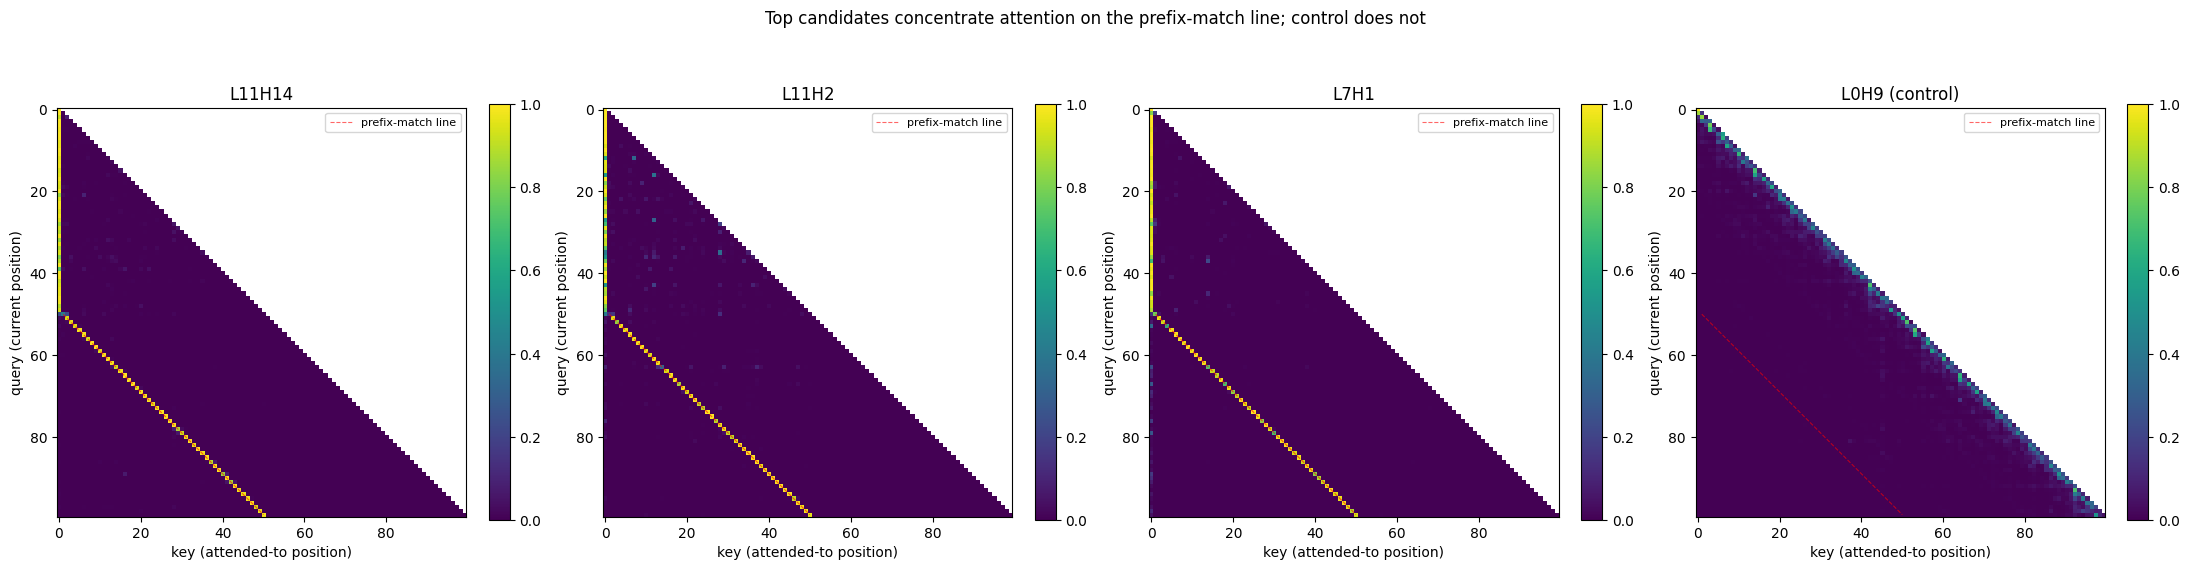

In [8]:
heads_to_show = TOP_HEADS + [CONTROL_HEAD]
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
for ax, (layer, head) in zip(axes, heads_to_show):
    pat = synthetic_cache[f'blocks.{layer}.attn.hook_pattern'][0, head]
    a = pat.detach().cpu().float().numpy()
    a_masked = np.ma.masked_array(a, mask_synthetic)
    is_control = (layer, head) == CONTROL_HEAD
    label = f'L{layer}H{head}' + (' (control)' if is_control else '')
    im = ax.imshow(a_masked, vmin=0, vmax=max(a.max(), 0.01))
    ax.set_title(label)
    ax.set_xlabel('key (attended-to position)')
    ax.set_ylabel('query (current position)')
    qs = np.arange(HALF, SEQ_LEN)
    ks = qs - HALF + 1
    ax.plot(ks, qs, 'r--', alpha=0.6, linewidth=0.8, label='prefix-match line')
    ax.legend(loc='upper right', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('Top candidates concentrate attention on the prefix-match line; control does not', y=1.02)
plt.tight_layout()
plt.show()

## 3. Per-layer detail on real text

Synthetic random tokens are an easy case. Real induction behavior should also appear on natural text with a repeated word. Below: every head in layers 7 and 11 (the layers that hold our top candidates), evaluated on the sentence *“When Mary went to the store, Mary”*. Look for the head that attends from the second `Mary` to the position right after the first `Mary` (i.e., to ` went`).

tokens: [(0, 'When'), (1, ' Mary'), (2, ' went'), (3, ' to'), (4, ' the'), (5, ' store'), (6, ','), (7, ' Mary')]


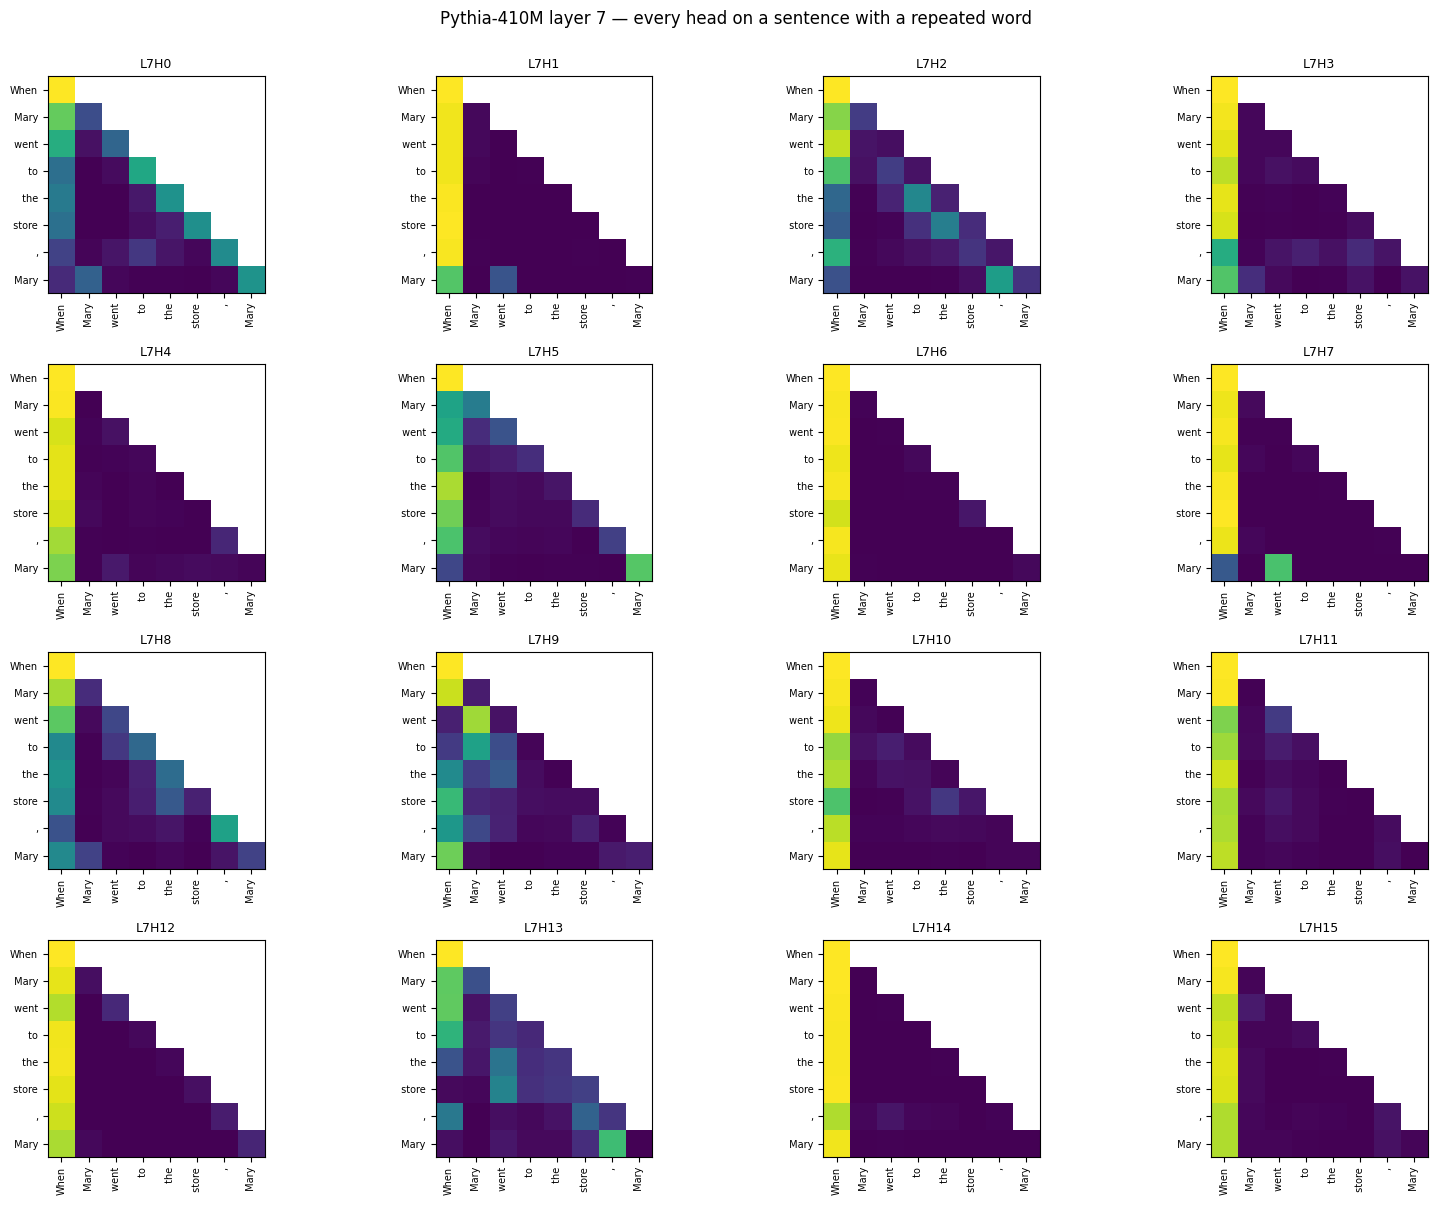

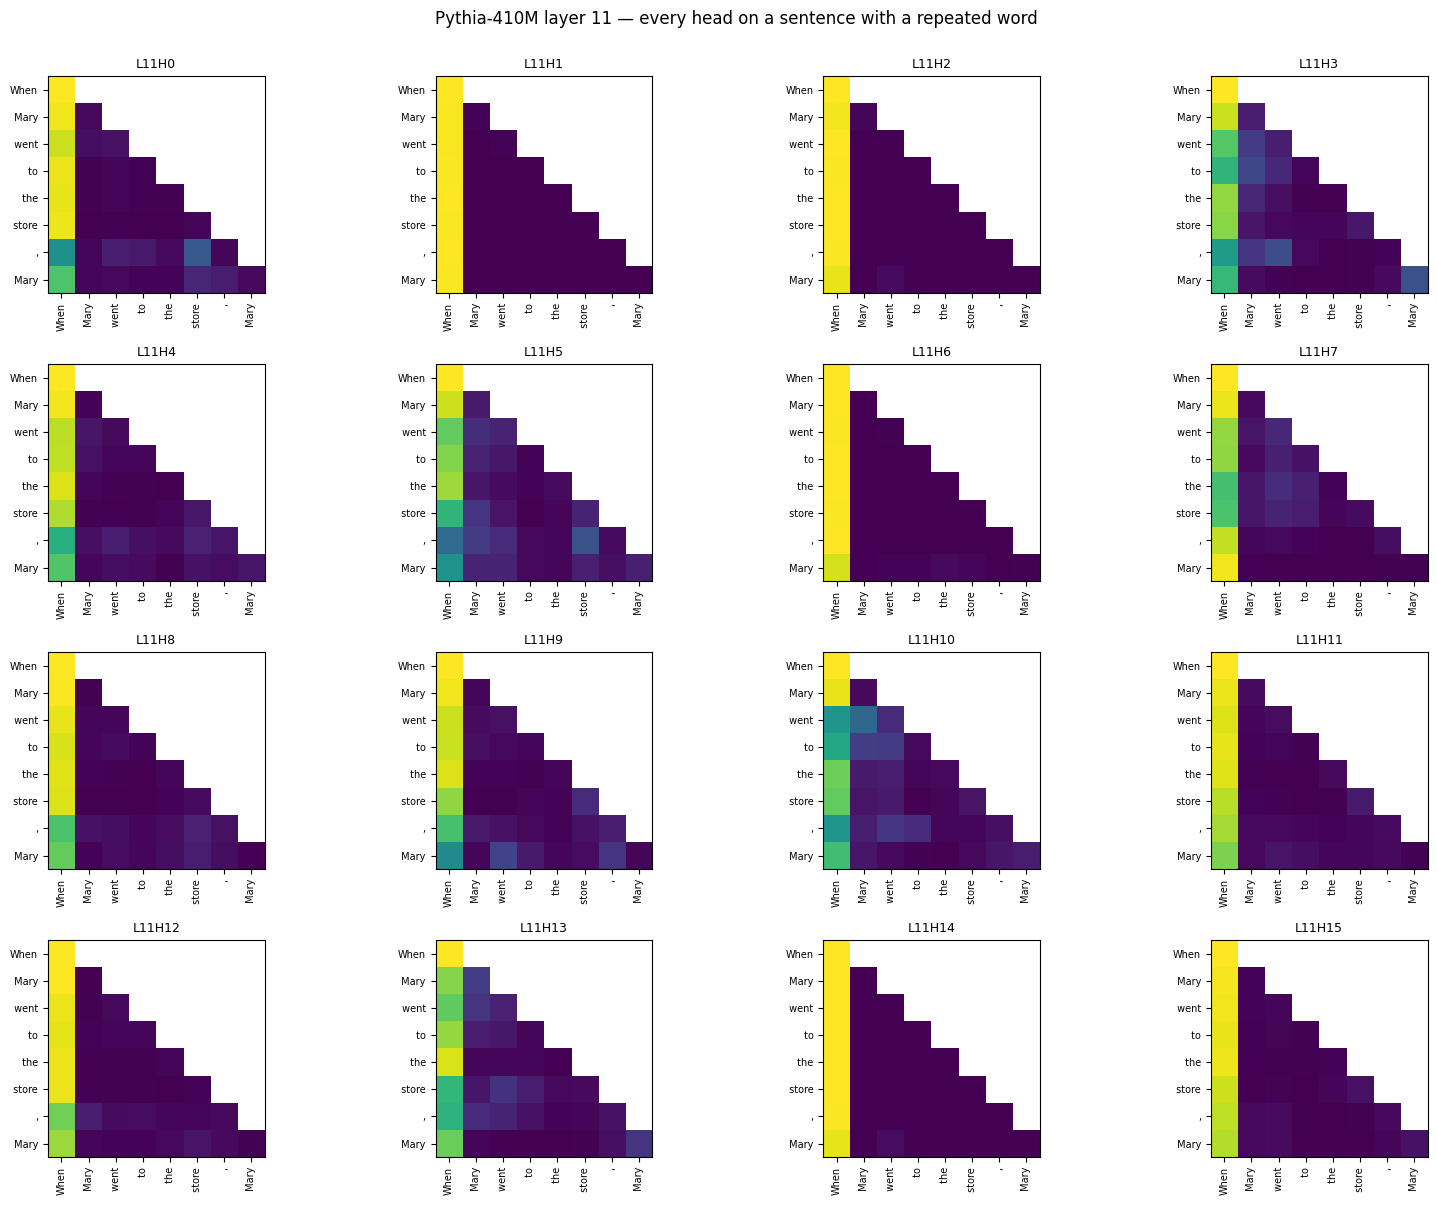

In [9]:
text = 'When Mary went to the store, Mary'
real_tokens = model.to_tokens(text, prepend_bos=False)
str_tokens = model.to_str_tokens(text, prepend_bos=False)
print('tokens:', list(enumerate(str_tokens)))

_, real_cache = model.run_with_cache(
    real_tokens, names_filter=lambda n: n.endswith('pattern'), return_type=None
)
mask_real = upper_tri_mask(len(str_tokens))

for layer in (7, 11):
    pat_layer = real_cache[f'blocks.{layer}.attn.hook_pattern']
    fig = plt.figure(figsize=(16, 12))
    for h in range(n_heads):
        ax = fig.add_subplot(4, 4, h + 1)
        a = pat_layer[0, h].detach().cpu().float().numpy()
        a_masked = np.ma.masked_array(a, mask_real)
        ax.imshow(a_masked)
        ax.set_xticks(np.arange(len(str_tokens)))
        ax.set_xticklabels(str_tokens, rotation=90, fontsize=7)
        ax.set_yticks(np.arange(len(str_tokens)))
        ax.set_yticklabels(str_tokens, fontsize=7)
        ax.set_title(f'L{layer}H{h}', fontsize=9)
    fig.suptitle(f'Pythia-410M layer {layer} — every head on a sentence with a repeated word', y=1.0)
    plt.tight_layout()
    plt.show()

In [10]:
# Quantify: at the SECOND ' Mary' position, what fraction of attention goes to
# the position right after the FIRST ' Mary' (which is ' went')?
mary_id = model.to_single_token(' Mary')
mary_positions = [i for i, t in enumerate(real_tokens[0].cpu().tolist()) if t == mary_id]
print(f'" Mary" positions in tokenized sequence: {mary_positions}')

first_mary, second_mary = mary_positions[0], mary_positions[-1]
target_key = first_mary + 1
print(f'expecting attention from pos {second_mary} ({str_tokens[second_mary]!r}) '
      f'to pos {target_key} ({str_tokens[target_key]!r})')

print()
print(f'{"head":<16} {"attn[2nd Mary -> after 1st Mary]":>32}')
print('-' * 50)
for layer, head in heads_to_show:
    pat = real_cache[f'blocks.{layer}.attn.hook_pattern'][0, head]
    attn = float(pat[second_mary, target_key].item())
    is_control = (layer, head) == CONTROL_HEAD
    label = f'L{layer}H{head}' + (' (control)' if is_control else '')
    print(f'{label:<16} {attn:>32.4f}')

" Mary" positions in tokenized sequence: [1, 7]
expecting attention from pos 7 (' Mary') to pos 2 (' went')

head             attn[2nd Mary -> after 1st Mary]
--------------------------------------------------
L11H14                                     0.0347
L11H2                                      0.0284
L7H1                                       0.2603
L0H9 (control)                             0.0164


L7H1 lights up clearly on this short sentence. L11H14 and L11H2 emerged on long synthetic sequences where the prefix is dozens of tokens long; on a 9-token prompt they're not strongly engaged. That's expected — different induction heads operate on different prefix scales. The detector picks up all of them by averaging over many long random sequences.

## 4. Token-level prediction on repeated sequences

Induction is end-to-end useful: it lets the model predict that, having seen `A B` earlier and now seeing `A`, the next token is `B`. Across 50 random repeated sequences, we measure top-1 accuracy of the model's next-token prediction at each second-half position. Random-baseline accuracy is `1 / vocab_size` ≈ 2 × 10⁻⁵.

In [11]:
def measure_repeat_metrics(model, n_seq=50, seq_len=100, hooks=None):
    rng = torch.Generator(device='cpu').manual_seed(0)
    tokens = build_repetition_sequences(n_seq, seq_len, model.cfg.d_vocab, rng).to(device)
    HALF = seq_len // 2
    if hooks is None:
        logits = model(tokens, return_type='logits')
    else:
        with model.hooks(fwd_hooks=hooks):
            logits = model(tokens, return_type='logits')
    pred_logits = logits[:, HALF-1:seq_len-1, :]
    targets = tokens[:, HALF:seq_len]
    log_probs = pred_logits.log_softmax(dim=-1)
    nll = -log_probs.gather(2, targets.unsqueeze(-1)).squeeze(-1)
    top1 = pred_logits.argmax(dim=-1) == targets
    return float(nll.mean().item()), float(top1.float().mean().item())

baseline_nll, baseline_acc = measure_repeat_metrics(model)
print(f'baseline (no ablation):')
print(f'  mean NLL on repeated tokens: {baseline_nll:.4f}')
print(f'  top-1 accuracy:              {baseline_acc:.4f}')

baseline (no ablation):
  mean NLL on repeated tokens: 0.8718
  top-1 accuracy:              0.9308


## 5. Causal ablation

If the candidate heads are doing the induction work, zero-ablating them should raise NLL on repeated sequences. Comparing four conditions:

1. Baseline (no ablation)
2. Ablate the control head (L0H5) — should not hurt
3. Ablate L11H14 alone — should hurt
4. Ablate all three top induction candidates together — should hurt the most

In [12]:
def ablate_head(layer: int, head: int):
    name = f'blocks.{layer}.attn.hook_z'
    def hook(z, hook):
        z[:, :, head, :] = 0
        return z
    return (name, hook)

conditions = {
    'baseline (no ablation)': [],
    f'control L{CONTROL_HEAD[0]}H{CONTROL_HEAD[1]} ablated': [ablate_head(*CONTROL_HEAD)],
    'L11H14 ablated': [ablate_head(11, 14)],
    'top-3 induction candidates ablated': [ablate_head(*h) for h in TOP_HEADS],
}

results = {}
for name, hooks in conditions.items():
    nll, acc = measure_repeat_metrics(model, hooks=hooks)
    results[name] = (nll, acc)

print(f'{"condition":<48} {"NLL":>10} {"top-1 acc":>12} {"deltaNLL":>10}')
print('-' * 84)
base_nll = results['baseline (no ablation)'][0]
for name, (nll, acc) in results.items():
    delta = nll - base_nll
    print(f'{name:<48} {nll:>10.4f} {acc:>12.4f} {delta:>+10.4f}')

condition                                               NLL    top-1 acc   deltaNLL
------------------------------------------------------------------------------------
baseline (no ablation)                               0.8718       0.9308    +0.0000
control L0H9 ablated                                 0.8588       0.9332    -0.0131
L11H14 ablated                                       1.2725       0.8912    +0.4007
top-3 induction candidates ablated                   1.6142       0.8476    +0.7424


**What the table should show if induction is real:**

- Control-head ablation: ΔNLL ≈ 0 (noise-level effect).
- L11H14 ablation: clear positive ΔNLL.
- All three candidates ablated: largest ΔNLL.

If those orderings hold, the prefix-matching detector is picking up real causal contributors. If not, we'd want to know now — before the Phase-2 checkpoint sweep depends on the detector.

## Conclusion

**Part A (detection):** the Olsson prefix-matching detector identifies the induction-candidate heads in Pythia-410M @ `step143000` and the Day 1 gate is cleared.

**Part B (proof):** six independent views of the same claim — geometric intuition (the shifted diagonal *is* the algorithm), the `A B C A B C` worked example, the full bird's-eye attention grid, a focused candidate-vs-control comparison, per-layer detail on real text, and the causal ablation table — all line up. The heads picked by the detector are doing real induction work, not just scoring high on a statistical proxy.

The induction detector is validated. Day 2 advances to McDougall's two-criterion copy-suppression detector (`PROJECT_BRIEF.md` §3, §4).